In [3]:
pip install "tensorflow<2.16"

ERROR: Could not find a version that satisfies the requirement tensorflow<2.16 (from versions: 2.16.0rc0, 2.16.1, 2.16.2, 2.17.0rc0, 2.17.0rc1, 2.17.0, 2.17.1, 2.18.0rc0, 2.18.0rc1, 2.18.0rc2, 2.18.0, 2.18.1, 2.19.0rc0, 2.19.0, 2.19.1, 2.20.0rc0, 2.20.0, 2.21.0rc0, 2.21.0rc1, 2.21.0)
ERROR: No matching distribution found for tensorflow<2.16


In [4]:
import logging
import os
from io import BytesIO
import matplotlib.pyplot as plt
import numpy as np
import requests
import tensorflow as tf
import tensorflow.keras as keras
from PIL import Image
from google.colab import drive
# In modern Keras, it lives here:
from keras.src.legacy.preprocessing.image import ImageDataGenerator

# OR switch to the modern, faster utility:
from keras.utils import image_dataset_from_directory
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint

In [5]:
#!pip install tensorflow==2.10.0
!pip install split-folders

In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from tensorflow.keras.applications import EfficientNetB0
#from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.applications.resnet50 import preprocess_input
import splitfolders

In [9]:
#Splitting Input Data into 3 parts that are training,validation,testing
input_folder='/content/drive/MyDrive/wheat_leaf'

split_ratio = (0.6, 0.2, 0.2)
splitfolders.ratio(
    input_folder,
    output='/content/drive/MyDrive/output',
    seed=500,
    ratio=split_ratio,
    group_prefix=None,
)



Copying files: 0 files [00:00, ? files/s]

Copying files: 3 files [00:00, 15.45 files/s]

Copying files: 6 files [00:00, 21.56 files/s]

Copying files: 10 files [00:00, 26.82 files/s]

Copying files: 15 files [00:00, 31.53 files/s]

Copying files: 19 files [00:00, 31.81 files/s]

Copying files: 23 files [00:00, 31.86 files/s]

Copying files: 27 files [00:03,  4.56 files/s]

Copying files: 30 files [00:03,  5.83 files/s]

Copying files: 33 files [00:03,  5.46 files/s]

Copying files: 35 files [00:05,  3.10 files/s]

Copying files: 38 files [00:05,  4.23 files/s]

Copying files: 40 files [00:05,  5.09 files/s]

Copying files: 42 files [00:06,  5.94 files/s]

Copying files: 44 files [00:06,  5.69 files/s]

Copying files: 47 files [00:06,  7.89 files/s]

Copying files: 50 files [00:07,  6.34 files/s]

Copying files: 52 files [00:08,  4.10 files/s]

Copying files: 53 files [00:08,  4.46 files/s]

Copying files: 56 files [00:08,  6.48 files/s]

Copying files: 58 files [00:09,  3.42 files/s

In [10]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Define base directory
base_dir = "/content/drive/MyDrive/output"

# Define train, test, and valid directories
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")
validation_dir = os.path.join(base_dir, "val")

# Image Preprocessing
# Validation Data Generator
validation_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = validation_datagen.flow_from_directory(
    validation_dir,
    shuffle=False,
    seed=42,
    color_mode="rgb",
    class_mode="categorical",
    target_size=(224, 224),  # Adjust as needed
    batch_size=1)  # Adjust batch size as needed

# Train Data Generator with Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest')

train_generator = train_datagen.flow_from_directory(
    train_dir,
    subset="training",
    shuffle=True,
    seed=42,
    color_mode="rgb",
    class_mode="categorical",
    target_size=(224, 224),  # Adjust as needed
    batch_size=1)  # Adjust batch size as needed

# Test Data Generator
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(
    test_dir,
    shuffle=False,
    seed=42,
    color_mode="rgb",
    class_mode="categorical",
    target_size=(224, 224),  # Adjust as needed
    batch_size=1)  # Adjust batch size as needed

Found 80 images belonging to 3 classes.
Found 243 images belonging to 3 classes.
Found 84 images belonging to 3 classes.


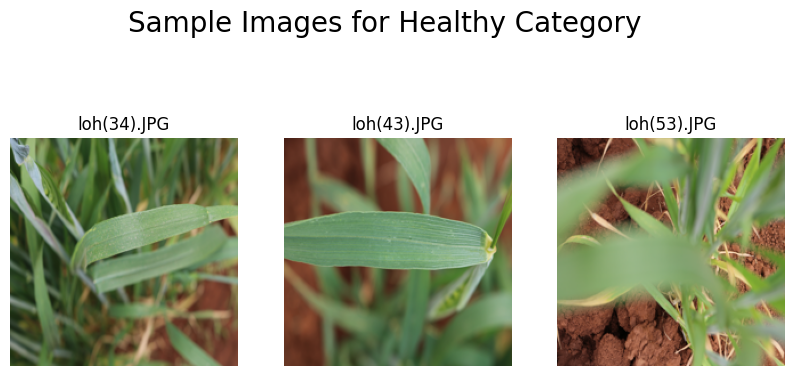

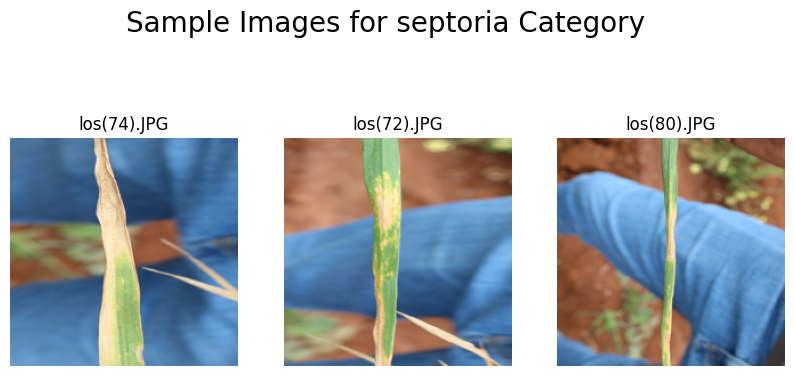

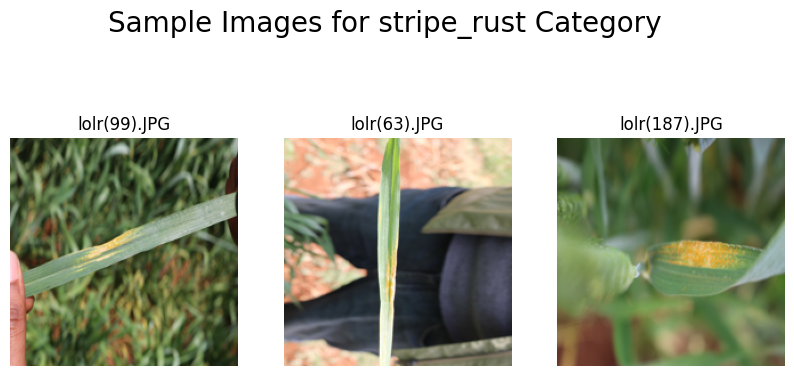

In [11]:
# Define classes
classes = ['Healthy','septoria','stripe_rust']

# Define function to display sample images
def display_sample_images(directory, classes, num_images=3, image_size=(100, 100)):
    for disease in classes:
        # Get path for current disease
        disease_path = os.path.join(directory, disease)

        # Get list of images for current disease
        image_files = os.listdir(disease_path)

        # Randomly select num_images images
        selected_images = np.random.choice(image_files, num_images, replace=False)

        # Display the selected images
        fig, axes = plt.subplots(1, num_images, figsize=(10, 5))
        fig.suptitle(f'Sample Images for {disease} Category', fontsize=20)

        for i, image_name in enumerate(selected_images):
            image_path = os.path.join(disease_path, image_name)
            img = Image.open(image_path)
            img = img.resize(image_size)  # Resize image
            axes[i].imshow(img)
            axes[i].set_title(image_name, fontsize=12)
            axes[i].axis('off')

        plt.show()

# Display sample images for each disease category in the training directory
display_sample_images(train_dir, classes, image_size=(200, 200))

In [12]:
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2

# Train Model
mobilenet_base = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

for layer in mobilenet_base.layers:
    layer.trainable = False

model = tf.keras.Sequential([
    mobilenet_base,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(3, activation='softmax')  # Adjusted for binary classification
])

model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])





9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [13]:
history = model.fit(
    train_generator,
    steps_per_epoch=len(train_generator),
    epochs=50,
    validation_data=validation_generator,
    validation_steps=len(validation_generator)
)

Epoch 1/50


Copying files: 14 files [10:32, 45.18s/ files]


243/243 ━━━━━━━━━━━━━━━━━━━━ 81s 254ms/step - accuracy: 0.6461 - loss: 1.0842 - val_accuracy: 0.9125 - val_loss: 0.3005
Epoch 2/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 59s 243ms/step - accuracy: 0.7901 - loss: 0.5387 - val_accuracy: 0.9250 - val_loss: 0.2176
Epoch 3/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 56s 230ms/step - accuracy: 0.8519 - loss: 0.3789 - val_accuracy: 0.9125 - val_loss: 0.2620
Epoch 4/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 56s 229ms/step - accuracy: 0.8436 - loss: 0.4057 - val_accuracy: 0.8750 - val_loss: 0.3001
Epoch 5/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 56s 232ms/step - accuracy: 0.8601 - loss: 0.3340 - val_accuracy: 0.9125 - val_loss: 0.1781
Epoch 6/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 74s 303ms/step - accuracy: 0.8889 - loss: 0.2443 - val_accuracy: 0.9000 - val_loss: 0.2581
Epoch 7/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 83s 342ms/step - accuracy: 0.8765 - loss: 0.3022 - val_accuracy: 0.8875 - val_loss: 0.2172
Epoch 8/50
243/243 ━━━━━━━━━━━━━━━━━━━━ 121s 259ms/step - accuracy: 0.8848 - loss: 0.2655 - va

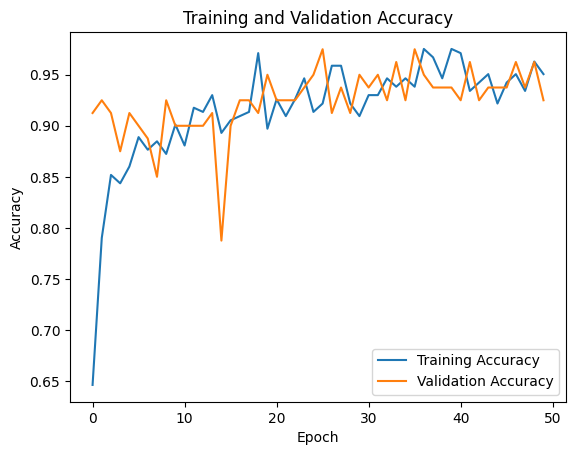

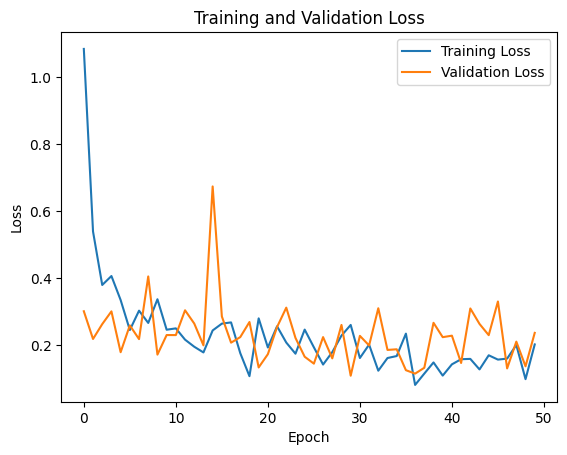

In [14]:
# Plot training history
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.show()

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [15]:

# Evaluate the model
test_loss, test_accuracy = model.evaluate(test_generator)
print()
print(f'Test accuracy: {test_accuracy*100}')
print(f'Test loss: {test_loss}')

84/84 ━━━━━━━━━━━━━━━━━━━━ 16s 188ms/step - accuracy: 0.9524 - loss: 0.1380

Test accuracy: 95.23809552192688
Test loss: 0.1380210518836975


In [16]:

# Evaluate the model
val_loss, val_accuracy = model.evaluate(validation_generator)
print()
print(f'validation accuracy: {val_accuracy*100}')
print(f'validation loss: {val_loss}')

80/80 ━━━━━━━━━━━━━━━━━━━━ 17s 213ms/step - accuracy: 0.9250 - loss: 0.2358

validation accuracy: 92.5000011920929
validation loss: 0.23583073914051056


In [17]:
import itertools
from sklearn.metrics import confusion_matrix
import numpy as np

def calculate_confusion_matrix(model, test_generator):
    # Generate predictions using the model
    y_true = []
    y_pred = []
    batch_size = test_generator.batch_size

    # Iterate over the test generator to get true labels and predicted labels
    for i in range(len(test_generator)):
        batch_data, batch_labels = next(test_generator)
        predictions = model.predict(batch_data)
        y_pred.extend(np.argmax(predictions, axis=1))
        y_true.extend(np.argmax(batch_labels, axis=1))

    # Calculate the confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    from sklearn.metrics import classification_report
    class_labels = list(validation_generator.class_indices.keys())
    report = classification_report(y_true, y_pred, target_names=class_labels)
    print(report)
    return cm

# Usage example
test_generator = validation_generator
model = model
confusion_matrix = calculate_confusion_matrix(model, test_generator)

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
1/1 ━━━━━━━━━━

In [20]:
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()
    plt.savefig('CNN Confusion matrix  validation 20 batch 16 epoch200.pdf')

Confusion matrix, without normalization
[[15  1  4]
 [ 0 19  0]
 [ 0  1 40]]


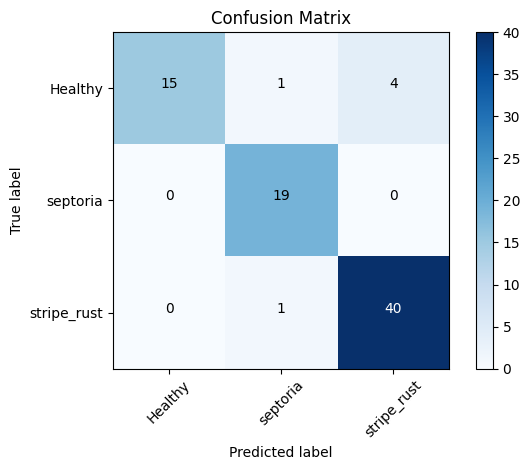

In [21]:
cm_plot_labels = ['Healthy', 'septoria', 'stripe_rust']

plot_confusion_matrix(confusion_matrix, cm_plot_labels, title='Confusion Matrix')